In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

D:\Deep Learning 2 (Final)\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [10]:
X,y = make_circles(n_samples=100,noise=0.1, random_state=1)

<Axes: >

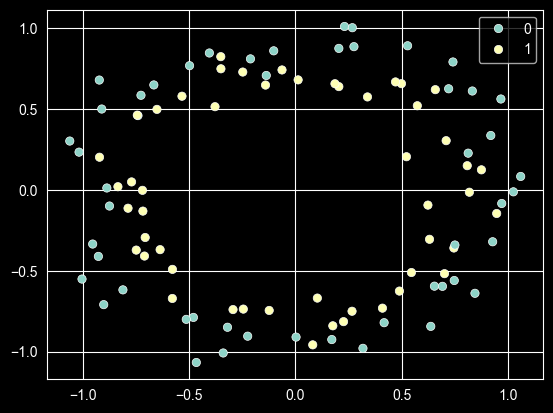

In [11]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [13]:
model = Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

D:\Deep Learning 2 (Final)\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
history = model.fit(X_train, y_train, epochs=1500, validation_data=(X_test, y_test))

Epoch 1/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4857 - loss: 0.6944 - val_accuracy: 0.5333 - val_loss: 0.6901
Epoch 2/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4857 - loss: 0.6923 - val_accuracy: 0.5333 - val_loss: 0.6897
Epoch 3/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4857 - loss: 0.6918 - val_accuracy: 0.5333 - val_loss: 0.6899
Epoch 4/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4857 - loss: 0.6906 - val_accuracy: 0.5333 - val_loss: 0.6902
Epoch 5/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4857 - loss: 0.6897 - val_accuracy: 0.5333 - val_loss: 0.6909
Epoch 6/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4857 - loss: 0.6889 - val_accuracy: 0.4667 - val_loss: 0.6922
Epoch 7/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5143 - loss: 0.6879 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5143 - loss: 0.6875 - val_accuracy: 0.5333 - v

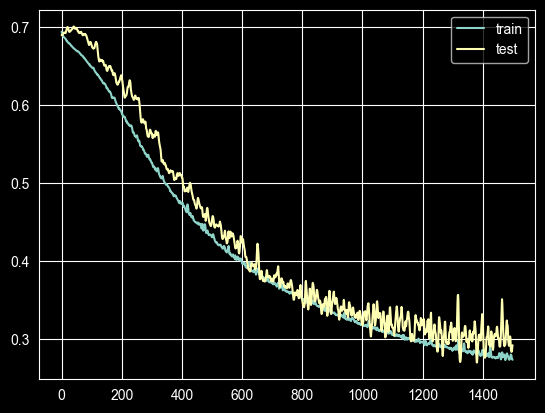

In [16]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 3s 327us/step


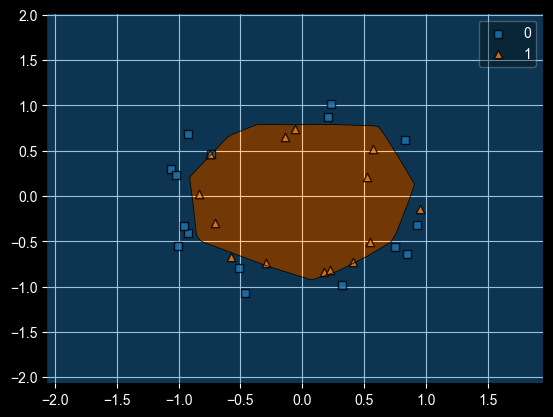

In [17]:
plot_decision_regions(X_test, y_test, clf=model)
plt.show()

# EARLY_STOPPING

In [18]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [19]:
callback=EarlyStopping(
    monitor="val_loss",
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)

In [20]:
history = model.fit(X_train, y_train, epochs=1500, validation_data=(X_test, y_test), callbacks=callback)

Epoch 1/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9000 - loss: 0.2757 - val_accuracy: 0.9000 - val_loss: 0.3056
Epoch 2/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.2769 - val_accuracy: 0.9000 - val_loss: 0.3183
Epoch 3/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9000 - loss: 0.2742 - val_accuracy: 0.9000 - val_loss: 0.3123
Epoch 4/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9000 - loss: 0.2720 - val_accuracy: 0.9000 - val_loss: 0.3000
Epoch 5/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9143 - loss: 0.2724 - val_accuracy: 0.9000 - val_loss: 0.2885
Epoch 6/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9000 - loss: 0.2752 - val_accuracy: 0.9000 - val_loss: 0.2826
Epoch 7/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8857 - loss: 0.2761 - val_accuracy: 0.9000 - val_loss: 0.2836
Epoch 8/1500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8857 - loss: 0.2756 - val_accuracy: 0.9000 - v

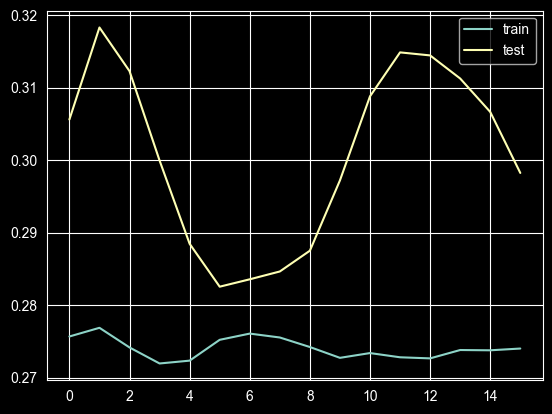

In [21]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 3s 326us/step


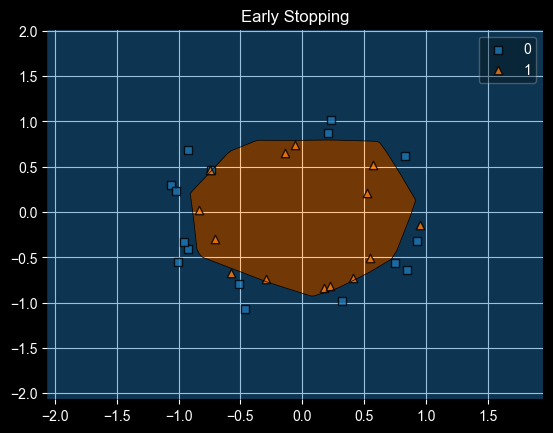

In [23]:
plot_decision_regions(X_test, y_test, clf=model)
plt.title('Early Stopping')
plt.show()